In [265]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr, mannwhitneyu, f_oneway

In [293]:
df = pd.read_csv(r'e_commerce_shopper_behaviour_and_lifestyle.csv')
df

,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,8,0,18,7,30,3,2026-06-23,3,0,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,36,Female,France,Urban,192880,Student,Master,In a relationship,0,...,4,3,26,2,50,21,2025-06-27,2,1,93
999996,999997,37,Male,Canada,Urban,197111,Unemployed,Master,Divorced,0,...,10,9,31,5,78,15,2025-06-05,7,1,97
999997,999998,71,Male,UK,Urban,171275,Unemployed,Bachelor,Married,1,...,6,5,19,7,8,16,2026-09-25,5,0,96
999998,999999,30,Female,Germany,Urban,124983,Employed,High School,Single,0,...,4,2,56,5,8,11,2026-10-25,2,0,46


In [294]:
def describe_df(data:pd.DataFrame, umbral_categorica:int=10, umbral_continua:float=0.1, imprimir:bool=True) -> pd.DataFrame:
    '''
    Genera una descripción esquemática de las variables de un DataFrame, devolviendo un nuevo DataFrame en el que cada columna corresponde
    a una variable del conjunto de datos original y cada fila resume una propiedad básica y una clasificación sugerida de dicha variable.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada sobre el que se calcula la descripción de variables.
    umbral_categorica : int, default=10
        Umbral de cardinalidad absoluta para considerar una variable como categórica nominal.
    umbral_continua : float, default=0.1
        Umbral de cardinalidad relativa a partir del cual una variable numérica o temporal se considera continua.
    imprimir : bool, default=True
        Indica si se imprime por pantalla un resumen de los umbrales utilizados en la clasificación.

    Returns
    -------
    pandas.DataFrame
        DataFrame resumen que contiene, para cada variable del DataFrame original, su tipo de dato, número y porcentaje de valores nulos,
        cardinalidad absoluta y relativa, y una clasificación sugerida del tipo de variable.
    '''

    if not(isinstance(data, pd.DataFrame)):
        raise TypeError('La variable "data" debe ser de un DataFrame.')
    if not(isinstance(umbral_categorica, int)):
        raise TypeError('La variable "umbral_categorica" debe ser un número entero.')
    if not(isinstance(umbral_continua, (int, float))):
        raise TypeError('La variable "umbral_continua" debe ser un número.')
    if not(0 <= umbral_continua <= 1):
        raise ValueError('El valor de "umbral_continua" debe estar comprendido entre 0 y 1.')
    if not(isinstance(imprimir, bool)):
        raise TypeError('La variable "imprimir" debe ser True/False.')
    
    salida = {columna: [] for columna in data.columns}
    for columna in salida.keys():
        tipo = data[columna].dtype
        nulos = data[columna].isna().sum()
        cardinalidad = data[columna].nunique()
        clasificacion = 'Bajo_Interes'

        if cardinalidad == 2:
            clasificacion = 'Categorica_Binaria'

        elif cardinalidad <= umbral_categorica:
            clasificacion = 'Categorica_Nominal'

        elif pd.api.types.is_numeric_dtype(tipo) or pd.api.types.is_datetime64_any_dtype(tipo):
            if cardinalidad / len(data) <= umbral_continua:
                clasificacion = 'Numerica_Discreta'
            else:
                clasificacion = 'Numerica_Continua'

        salida[columna].append(tipo)
        salida[columna].append(nulos)
        salida[columna].append(round(nulos / len(data) * 100, 1))
        salida[columna].append(cardinalidad)
        salida[columna].append(round(cardinalidad / len(data) * 100, 2))
        salida[columna].append(clasificacion)

    salida['Columnas'] = ['Tipo_Dato', 'Nulos', 'Nulos_%', 'Cardinalidad', 'Cardinalidad_%', 'Clasificacion_sugerida']

    if imprimir:
        print(f'Clasificación sugerida para {len(data)} filas, con un umbral para categórica nominal de {umbral_categorica\
                } sobre la cardinalidad y un umbral para númerica continua de {umbral_continua*100} % sobre la cardinalidad relativa.')
    return pd.DataFrame(salida).set_index('Columnas')

In [295]:
des = describe_df(df, 10, 0.3)
des

Clasificación sugerida para 1000000 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 30.0 % sobre la cardinalidad relativa.


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
Columnas,,,,,,,,,,,,,,,,,,,,,
Tipo_Dato,int64,int64,object,object,object,int64,object,object,object,int64,...,int64,int64,int64,int64,int64,int64,object,int64,int64,int64
Nulos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nulos_%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cardinalidad,1000000,63,4,10,3,188991,5,5,5,2,...,10,11,101,8,101,24,731,9,2,101
Cardinalidad_%,100.0,0.01,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.01,0.0,0.01,0.0,0.07,0.0,0.0,0.01
Clasificacion_sugerida,Numerica_Continua,Numerica_Discreta,Categorica_Nominal,Categorica_Nominal,Categorica_Nominal,Numerica_Discreta,Categorica_Nominal,Categorica_Nominal,Categorica_Nominal,Categorica_Binaria,...,Categorica_Nominal,Numerica_Discreta,Numerica_Discreta,Categorica_Nominal,Numerica_Discreta,Numerica_Discreta,Bajo_Interes,Categorica_Nominal,Categorica_Binaria,Numerica_Discreta


In [296]:
for columna in des:
    if des.loc['Nulos', columna] >= 1:
        df.drop(columns=columna, inplace=True)

In [297]:
describe_df(df)

Clasificación sugerida para 1000000 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
Columnas,,,,,,,,,,,,,,,,,,,,,
Tipo_Dato,int64,int64,object,object,object,int64,object,object,object,int64,...,int64,int64,int64,int64,int64,int64,object,int64,int64,int64
Nulos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nulos_%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cardinalidad,1000000,63,4,10,3,188991,5,5,5,2,...,10,11,101,8,101,24,731,9,2,101
Cardinalidad_%,100.0,0.01,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.01,0.0,0.01,0.0,0.07,0.0,0.0,0.01
Clasificacion_sugerida,Numerica_Continua,Numerica_Discreta,Categorica_Nominal,Categorica_Nominal,Categorica_Nominal,Numerica_Continua,Categorica_Nominal,Categorica_Nominal,Categorica_Nominal,Categorica_Binaria,...,Categorica_Nominal,Numerica_Discreta,Numerica_Discreta,Categorica_Nominal,Numerica_Discreta,Numerica_Discreta,Bajo_Interes,Categorica_Nominal,Categorica_Binaria,Numerica_Discreta


In [298]:
def tipifica_variables(data:pd.DataFrame, umbral_categorica:int=10, umbral_continua:float=0.1) -> dict:
    '''
    Asigna una tipificación sugerida a las variables de un DataFrame en función de su cardinalidad y naturaleza, agrupándolas según su
    posible uso analítico como variables categóricas o numéricas.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada con las variables a analizar.
    umbral_categorica : int, default=10
        Umbral de cardinalidad absoluta para considerar una variable como categórica.
    umbral_continua : float, default=0.1
        Umbral de cardinalidad relativa a partir del cual una variable numérica se considera continua.

    Returns
    -------
    dict
        Diccionario cuyas claves corresponden a los tipos sugeridos de variable y cuyos valores son listas con los nombres de las
        columnas del DataFrame original asociadas a cada tipo.
    '''

    describe_data = describe_df(data, umbral_categorica, umbral_continua, False)
    diccionario = {'Categorica_Binaria': [], 'Categorica_Nominal': [], 'Numerica_Discreta': [], 'Numerica_Continua': [], 'Bajo_Interes': []}
    [diccionario[describe_data.loc['Clasificacion_sugerida', columna]].append(columna) for columna in describe_data.columns]

    return diccionario

In [299]:
tipifica_variables(df, 10, 0.1)

{'Categorica_Binaria': ['has_children',
  'loyalty_program_member',
  'weekend_shopper',
  'health_conscious_shopping',
  'premium_subscription'],
 'Categorica_Nominal': ['gender',
  'country',
  'urban_rural',
  'employment_status',
  'education_level',
  'relationship_status',
  'household_size',
  'occupation',
  'ethnicity',
  'language_preference',
  'device_type',
  'review_writing_frequency',
  'preferred_payment_method',
  'coupon_usage_frequency',
  'product_category_preference',
  'shopping_time_of_day',
  'impulse_purchases_per_month',
  'budgeting_style',
  'hobby_count',
  'exercise_frequency',
  'sleep_quality',
  'ad_clicks_per_day',
  'cart_items_average',
  'app_usage_frequency',
  'social_sharing_frequency'],
 'Numerica_Discreta': ['age',
  'weekly_purchases',
  'monthly_spend',
  'cart_abandonment_rate',
  'average_order_value',
  'referral_count',
  'browse_to_buy_ratio',
  'return_frequency',
  'brand_loyalty_score',
  'impulse_buying_score',
  'environmental_consc

In [302]:
def get_features_num_regression(data:pd.DataFrame, target_col:str, umbral_corr:float=0.4, pvalue:float=0.05, variables_tipificadas:dict=None) -> pd.DataFrame:
    '''
    Selecciona las variables numéricas de un DataFrame que presentan una relación lineal significativa con una variable objetivo,
    atendiendo a un umbral mínimo de correlación y a un nivel de significación estadística.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada que contiene las variables explicativas y la variable objetivo.
    target_col : str
        Nombre de la columna que se utilizará como variable objetivo del modelo de regresión.
    umbral_corr : float, default=0.4
        Valor mínimo de correlación (en valor absoluto) requerido para que una variable sea seleccionada.
    pvalue : float, default=0.05
        Nivel de significación estadística máximo permitido en el test de correlación.
    variables_tipificadas : dict, optional
        Diccionario con la tipificación previa de las variables; si no se proporciona, se calcula internamente.

    Returns
    -------
    pandas.DataFrame
        DataFrame con las variables numéricas seleccionadas, incluyendo su correlación con la variable objetivo y el p-value
        asociado al test estadístico.
    '''


    if not(isinstance(target_col, str)):
        raise TypeError('La variable "target_col" debe ser de un string.')
    if not(isinstance(umbral_corr, (int, float))):
        raise TypeError('La variable "umbral_corr" debe ser un número.')
    if not(0 <= umbral_corr <= 1):
        raise ValueError('El valor de "umbral_corr" debe estar comprendido entre 0 y 1.')
    if not(isinstance(pvalue, (int, float))):
        raise TypeError('La variable "pvalue" debe ser un número.')
    if not(0 <= pvalue <= 1):
        raise ValueError('El valor de "pvalue" debe estar comprendido entre 0 y 1.')
    
    if variables_tipificadas == None:
        variables_tipificadas = tipifica_variables(data)
    elif not(isinstance(variables_tipificadas, dict)):
        raise TypeError('La variable "variables_tipificadas" debe ser de un diccionario.')

    if not target_col in variables_tipificadas['Numerica_Continua']:
        raise ValueError('La columna "target_col" debe ser "Numerica_Continua".')

    data = data.dropna(axis=0)

    columnas_numericas = [columna for numericas in ['Numerica_Continua', 'Numerica_Discreta'] for columna in variables_tipificadas[numericas]]
    salida = {}
    for columna in columnas_numericas:
        if columna != target_col:
            corr_calc, pvalue_calc = pearsonr(data[columna], data[target_col])
            if corr_calc >= umbral_corr and pvalue_calc <= pvalue:
                salida[columna] = [corr_calc, pvalue_calc]

    return pd.DataFrame(salida, index=['Correlacion', 'P_value'])

In [303]:
get_features_num_regression(df, 'income_level')

""
Correlacion
P_value


In [304]:
def plot_features_num_regression(data:pd.DataFrame, target_col:str, columns:list=[], umbral_corr:float=0.4, pvalue:float=0.05) -> list:
    '''
    Genera gráficos de dispersión entre una variable objetivo y un conjunto de variables numéricas seleccionadas en función
    de su correlación y significación estadística.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada que contiene las variables numéricas y la variable objetivo.
    target_col : str
        Nombre de la columna que se utilizará como variable objetivo.
    columns : list of str, default=[]
        Columna o lista de columnas candidatas a representar; si está vacía, se consideran todas las variables numéricas del DataFrame.
    umbral_corr : float, default=0.4
        Valor mínimo de correlación requerido para que una variable sea representada.
    pvalue : float, default=0.05
        Nivel de significación estadística máximo permitido en el test de correlación.

    Returns
    -------
    list
        Lista de nombres de las variables que cumplen los criterios y han sido representadas gráficamente.
    '''


    columns = data.columns.to_list() if columns == [] else columns
    if isinstance(columns, str):
        columns = [columns]
    if not(isinstance(columns, list)):
        raise TypeError('La variable "columns" debe ser de un solo string o una lista.')
    
    data = data.dropna(axis=0)

    columns_calc = get_features_num_regression(data, target_col, umbral_corr, pvalue)

    columnas_pintar = [col for col in columns if col in columns_calc.columns]
    
    divisiones = math.ceil(len(columnas_pintar) / 4)
    for div in range(divisiones):
        ncols = min(4, len(columnas_pintar)-div*4)
        _, axs = plt.subplots(ncols=min(4, len(columnas_pintar)-div*4), figsize = (5*ncols, 5))
        axs = axs if isinstance(axs, np.ndarray) else [axs]
        for i, ax in enumerate(axs):
            idx = div * 4 + i
            sns.scatterplot(data, x=columnas_pintar[idx], y=target_col, ax=ax)

            ax.set_xlabel(f'{columnas_pintar[idx]} | corr = {columns_calc[columnas_pintar[idx]]['Correlacion']:.3g} | p-value = {columns_calc[columnas_pintar[idx]]['P_value']:.3g}')
            if i != 0:
                ax.set_ylabel('')
            else:
                ax.set_ylabel(target_col)

    return columnas_pintar

In [305]:
plot_features_num_regression(df, 'income_level')

[]

In [306]:
def get_features_cat_regression(data:pd.DataFrame, target_col:str, pvalue:float=0.05, variables_tipificadas:dict=None) -> pd.DataFrame:
    '''
    Identifica las variables categóricas de un DataFrame cuya relación con una variable objetivo numérica resulta estadísticamente
    significativa según el test de hipótesis adecuado en cada caso.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada que contiene las variables categóricas y la variable objetivo.
    target_col : str
        Nombre de la columna que actúa como variable objetivo numérica continua.
    pvalue : float, default=0.05
        Nivel de significación estadística máximo permitido en los tests de relación.
    variables_tipificadas : dict, optional
        Diccionario con la tipificación previa de las variables; si no se proporciona, se calcula internamente.

    Returns
    -------
    pandas.DataFrame
        DataFrame con una fila que recoge el p-valor asociado a cada variable categórica cuya relación con la variable objetivo
        resulta estadísticamente significativa.
    '''


    if not(isinstance(target_col, str)):
        raise TypeError('La variable "target_col" debe ser de un string.')
    if not(isinstance(pvalue, (int, float))):
        raise TypeError('La variable "pvalue" debe ser un número.')
    if not(0 <= pvalue <= 1):
        raise ValueError('El valor de "pvalue" debe estar comprendido entre 0 y 1.')

    if variables_tipificadas == None:
        variables_tipificadas = tipifica_variables(data)
    elif not(isinstance(variables_tipificadas, dict)):
        raise TypeError('La variable "variables_tipificadas" debe ser de un diccionario.')

    if not target_col in variables_tipificadas['Numerica_Continua']:
        raise ValueError('La columna "target_col" debe ser "Numerica_Continua".')
    
    data = data.dropna(axis=0)

    columnas_categoricas = [columna for categoricas in ['Categorica_Binaria', 'Categorica_Nominal'] for columna in variables_tipificadas[categoricas]]
    salida = {}
    for columna in columnas_categoricas:
        if data[columna].nunique() == 2:
            grupo_a, grupo_b = [data[data[columna] == valor][target_col] for valor in data[columna].unique()]

            _, p_valor = mannwhitneyu(grupo_a, grupo_b)
            if p_valor <= pvalue:
                salida[columna] = p_valor
        else:
            lista = [data[data[columna] == valor][target_col] for valor in data[columna].unique()]
            _, p_valor = f_oneway(*lista)
            if p_valor <= pvalue:
                salida[columna] = p_valor
            
    return pd.DataFrame(salida, index=['P_value'])


In [307]:
get_features_cat_regression(df, 'income_level')

,loyalty_program_member,urban_rural,employment_status
P_value,0.006009,0.015393,0.046994


In [308]:
def plot_features_cat_regression(data:pd.DataFrame, target_col:str, columns:list=[], pvalue:float=0.05, with_individual_plot:bool=False) -> None:
    '''
    Visualiza la distribución de una variable objetivo numérica condicionada por variables categóricas cuya relación resulta
    estadísticamente significativa, generando gráficos de densidad para facilitar su comparación.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame de entrada que contiene las variables categóricas y la variable objetivo.
    target_col : str
        Nombre de la columna que actúa como variable objetivo numérica.
    columns : list of str, optional
        Lista de variables categóricas candidatas a representar; si está vacía, se consideran todas las categóricas.
    pvalue : float, default=0.05
        Nivel de significación estadística máximo permitido en los tests de relación.
    with_individual_plot : bool, default=False
        Indica si los gráficos se generan separando individualmente los valores de cada variable categórica.

    Returns
    -------
    list
        Lista de nombres de variables categóricas finalmente representadas.
    '''


    columns = data.columns.to_list() if columns == [] else columns
    if isinstance(columns, str):
        columns = [columns]
    if not(isinstance(columns, list)):
        raise TypeError('La variable "columns" debe ser de un solo string o una lista.') 
    if not isinstance(with_individual_plot, bool):
        raise TypeError('La variable "with_individual_plot" debe ser True/False.')
    
    data = data.dropna(axis=0)

    columns_calc = get_features_cat_regression(data, target_col, pvalue)

    columnas_pintar = [col for col in columns if col in columns_calc.columns]

    if with_individual_plot:
        for columna in columnas_pintar:
            valores = data[columna].unique()
            divisiones = math.ceil(len(valores) / 4)
            for div in range(divisiones):
                ncols = min(4, len(valores)-div*4)
                _, axs = plt.subplots(ncols=min(4, len(valores)-div*4), figsize = (5*ncols, 5))
                axs = axs if isinstance(axs, np.ndarray) else [axs]
                for i, ax in enumerate(axs):
                    idx = div * 4 + i
                    sns.kdeplot(data[data[columna] == valores[idx]], x=target_col, ax=ax, fill=True, alpha=0.3)
                    ax.set_xlabel(valores[idx])
                    if i != 0:
                        ax.set_ylabel('')
                    else:
                        ax.set_ylabel(f'{columna} - p-value = {columns_calc[columna]['P_value']:.3g}')

    else:
        divisiones = math.ceil(len(columnas_pintar) / 2)
        for div in range(divisiones):
            ncols = min(2, len(columnas_pintar)-div*2)
            _, axs = plt.subplots(ncols=min(2, len(columnas_pintar)-div*2), figsize = (10*ncols, 10))
            axs = axs if isinstance(axs, np.ndarray) else [axs]
            for i, ax in enumerate(axs):
                idx = div * 2 + i
                sns.kdeplot(data, x=target_col, hue=columnas_pintar[idx], ax=ax, fill=True, alpha=0.3)

                ax.set_xlabel(f'{columnas_pintar[idx]} - p-value = {columns_calc[columnas_pintar[idx]]['P_value']:.3g}')
                ax.set_ylabel('')
    
    return columnas_pintar


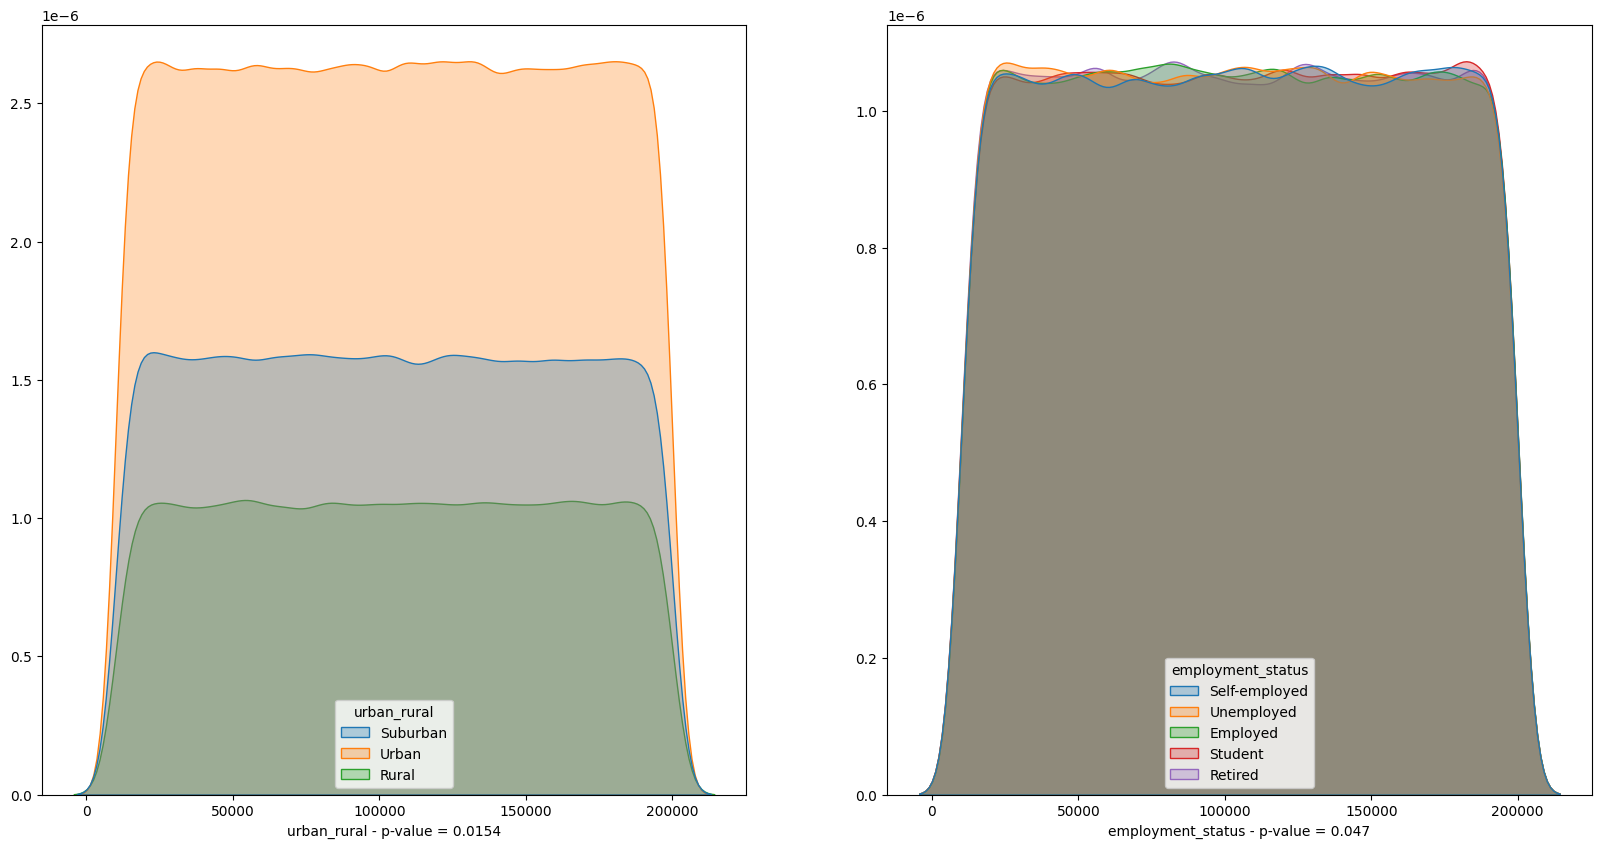

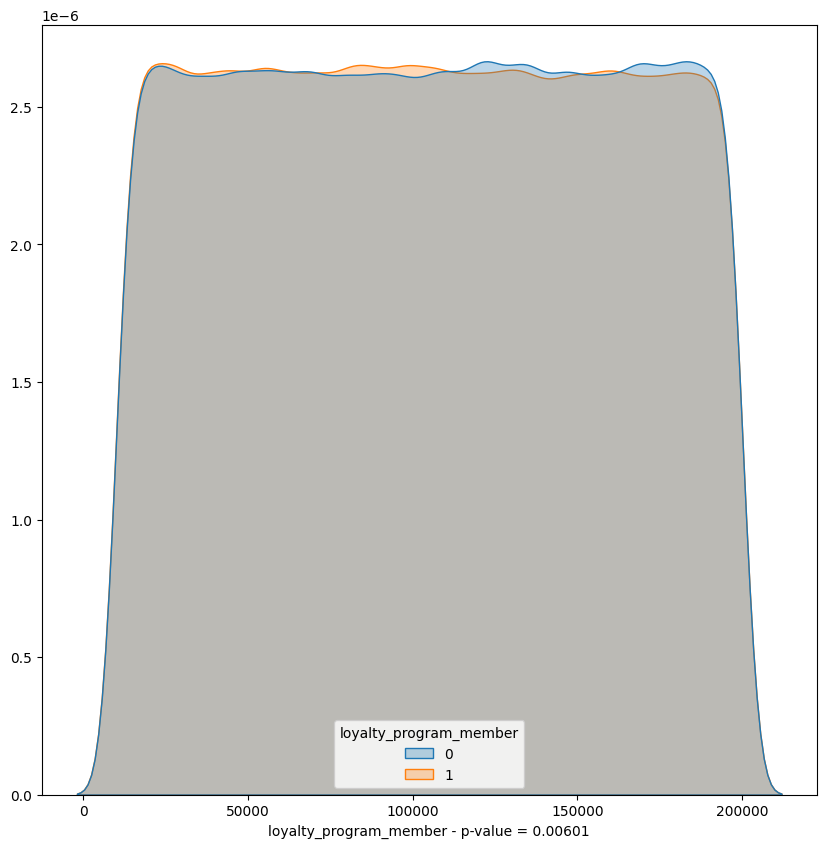

In [310]:
plot_features_cat_regression(df, 'income_level', with_individual_plot=False);